# 🛒 E-Commerce Product Recommendation — End-to-End ML Pipeline

**Author:** *[Your Name]*  
**Date:** 2025  
**Tools:** Python · Pandas · Scikit-learn · XGBoost · Matplotlib · Seaborn

---

## 📌 Project Overview

E-commerce platforms rely on **recommendation engines** to personalize the shopping experience and drive conversions.  
This project builds a full machine-learning pipeline to **predict the probability that a product will be recommended to a user**, based on behavioural, contextual, and product-level features.

### 🎯 Objective
Predict `probability_for_the_product_to_be_recommended_to_the_person` — a continuous score — using regression models.

### 🗂️ Pipeline Stages
| Stage | Description |
|-------|-------------|
| 1. Data Loading & Exploration | Understand the raw dataset |
| 2. Data Cleaning | Handle nulls, duplicates, inconsistencies |
| 3. Exploratory Data Analysis (EDA) | Visualise distributions and relationships |
| 4. Feature Engineering | Create new informative features |
| 5. Modelling | Train and evaluate multiple regression models |
| 6. Model Comparison & Insights | Select the best model and explain its decisions |

> **No data leakage guarantee:** The train/test split is performed *before* scaling and after encoding. The scaler is fit only on training data.

---
## 1. 📦 Imports & Configuration

In [6]:
# ── Core ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
PALETTE = 'coolwarm'
TARGET  = 'probability_for_the_product_to_be_recommended_to_the_person'

# ── Modelling ─────────────────────────────────────────────────────────────
from sklearn.model_selection   import train_test_split, cross_val_score
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LinearRegression, Ridge
from sklearn.ensemble          import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics           import mean_squared_error, mean_absolute_error, r2_score
from xgboost                   import XGBRegressor

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded ✓')

Libraries loaded ✓


---
## 2. 🗄️ Load Dataset

In [7]:
df_raw = pd.read_csv('../data/data.csv')

print(f'Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Memory : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')
df_raw.head()

Shape  : 1,474 rows × 13 columns
Memory : 491.8 KB


,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Gender,Median purchasing price (in rupees),Rating of the product,Brand of the product,Customer review sentiment score (overall),Price of the product,Holiday,Season,Geographical locations,Probability for the product to be recommended to the person
0,12,4,4.2000,male,500,4.5000,PUMA,0.8000,200,No,winter,plains,0.9000
1,8,2,3.8000,female,3000,3.2000,Lee,-0.4000,300,Yes,monsoon,mountains,0.2000
2,25,10,4.5000,female,600,4.8000,Head Hunters,0.6000,1000,No,spring,plains,0.7000
3,6,1,2.1000,female,100,2.5000,Johnson & Johnson,0.1000,300,No,summer,coastal,0.1000
4,18,5,4.7000,male,2000,4.3000,Wakefit,0.9000,700,Yes,winter,plains,0.8000


---
## 3. 🔍 Initial Exploration

In [8]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 13 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Number of clicks on similar products                         1474 non-null   int64  
 1   Number of similar products purchased so far                  1474 non-null   int64  
 2   Average rating given to similar products                     1474 non-null   float64
 3   Gender                                                       1474 non-null   object 
 4   Median purchasing price (in rupees)                          1474 non-null   int64  
 5   Rating of the product                                        1474 non-null   float64
 6   Brand of the product                                         1474 non-null   object 
 7   Customer review sentiment score (overall)                    1474 non-null   f

In [9]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Number of clicks on similar products,1474.0000,NaN,NaN,NaN,20.8467,11.3157,0.0000,11.0000,19.0000,28.7500,55.0000
Number of similar products purchased so far,1474.0000,NaN,NaN,NaN,9.2252,5.3566,0.0000,5.0000,9.0000,13.0000,24.0000
Average rating given to similar products,1474.0000,NaN,NaN,NaN,3.9710,0.8323,0.0000,3.4000,4.2000,4.7000,5.0000
Gender,1474,2,male,754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Median purchasing price (in rupees),1474.0000,NaN,NaN,NaN,2720.2849,3045.8984,100.0000,500.0000,1000.0000,5000.0000,19000.0000
Rating of the product,1474.0000,NaN,NaN,NaN,4.0594,0.8299,0.0000,3.5000,4.3000,4.8000,5.0000
Brand of the product,1474,48,Wildcraft,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer review sentiment score (overall),1474.0000,NaN,NaN,NaN,0.4735,0.5039,-1.0000,0.1000,0.7000,0.9000,1.0000
Price of the product,1474.0000,NaN,NaN,NaN,1142.9104,1961.0691,90.0000,400.0000,600.0000,900.0000,10000.0000
Holiday,1474,2,No,868,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# ── Categorical column overview ────────────────────────────────────────────
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numeric columns    ({len(num_cols)}): {num_cols}')

Categorical columns (5): ['Gender', 'Brand of the product', 'Holiday', 'Season', 'Geographical locations']
Numeric columns    (8): ['Number of clicks on similar products', 'Number of similar products purchased so far', 'Average rating given to similar products', 'Median purchasing price (in rupees)', 'Rating of the product', 'Customer review sentiment score (overall)', 'Price of the product', 'Probability for the product to be recommended to the person']


---
## 4. 🧹 Data Cleaning

### 4.1 Missing Values

In [11]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_df = (
    pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    .query('`Missing Count` > 0')
    .sort_values('Missing %', ascending=False)
)

if missing_df.empty:
    print('✅  No missing values detected.')
else:
    print(missing_df)
    # Imputation strategy:
    #   Numeric  → median (robust to outliers)
    #   Categorical → mode
    for col in missing_df.index:
        if df_raw[col].dtype == 'object':
            df_raw[col].fillna(df_raw[col].mode()[0], inplace=True)
        else:
            df_raw[col].fillna(df_raw[col].median(), inplace=True)
    print('Imputation applied.')

✅  No missing values detected.


### 4.2 Duplicate Rows

In [12]:
n_dupes = df_raw.duplicated().sum()
print(f'Duplicate rows found: {n_dupes}')

df = df_raw.drop_duplicates().reset_index(drop=True)
print(f'Shape after deduplication: {df.shape}')

Duplicate rows found: 456
Shape after deduplication: (1018, 13)


### 4.3 Standardise Categorical Values

In [13]:
# Strip whitespace and lowercase all text columns to avoid hidden mismatches
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

print('Unique values per categorical column after standardisation:')
for col in cat_cols:
    print(f'  {col:40s} → {df[col].unique()}')

Unique values per categorical column after standardisation:
  Gender                                   → ['male' 'female']
  Brand of the product                     → ['puma' 'lee' 'head hunters' 'johnson & johnson' 'wakefit'
 'dabur chyawanprash' 'manyavar mohey' 'pepperfry' 'lee cooper' 'libram'
 'flying machine' 'sleepycat' 'streax' 'lakme ayurveda'
 'forest essentials' 'dove hair' 'pepe jeans london' 'the moms co.'
 'himalaya liv.52' 'wildcraft' 'godrej interio'
 'patanjali ayurved (health care)' 'lijoba' 'moov' 'kama ayurveda'
 'urban ladder' 'allen solly woman' 'max' 'head & shoulders' 'fastrack'
 'sugar cosmetics' 'parachute' 'dettol' 'amazonbasics'
 'u.s. polo assn. women' 'khadi essentials' 'whisper'
 'levis strauss & co.' 'wild stone' 'biovea' 'vero moda' 'zandu' 'hrx'
 'mothercare' 'duroflex' 'spyker' 'stayfree' 'baidyanath']
  Holiday                                  → ['no' 'yes']
  Season                                   → ['winter' 'monsoon' 'spring' 'summer']
  Geogra

### 4.4 Rename Columns to snake_case

In [14]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[()]', '', regex=True)
)
print('Columns after renaming:')
print(df.columns.tolist())

Columns after renaming:
['number_of_clicks_on_similar_products', 'number_of_similar_products_purchased_so_far', 'average_rating_given_to_similar_products', 'gender', 'median_purchasing_price_in_rupees', 'rating_of_the_product', 'brand_of_the_product', 'customer_review_sentiment_score_overall', 'price_of_the_product', 'holiday', 'season', 'geographical_locations', 'probability_for_the_product_to_be_recommended_to_the_person']


### 4.5 Outlier Detection & Treatment

**Strategy:** Use the IQR method to *detect* outliers, then apply **Winsorisation** (capping) on business-relevant continuous features.  
Domain-constrained columns (e.g. ratings 0–5, probabilities 0–1) are intentionally excluded.

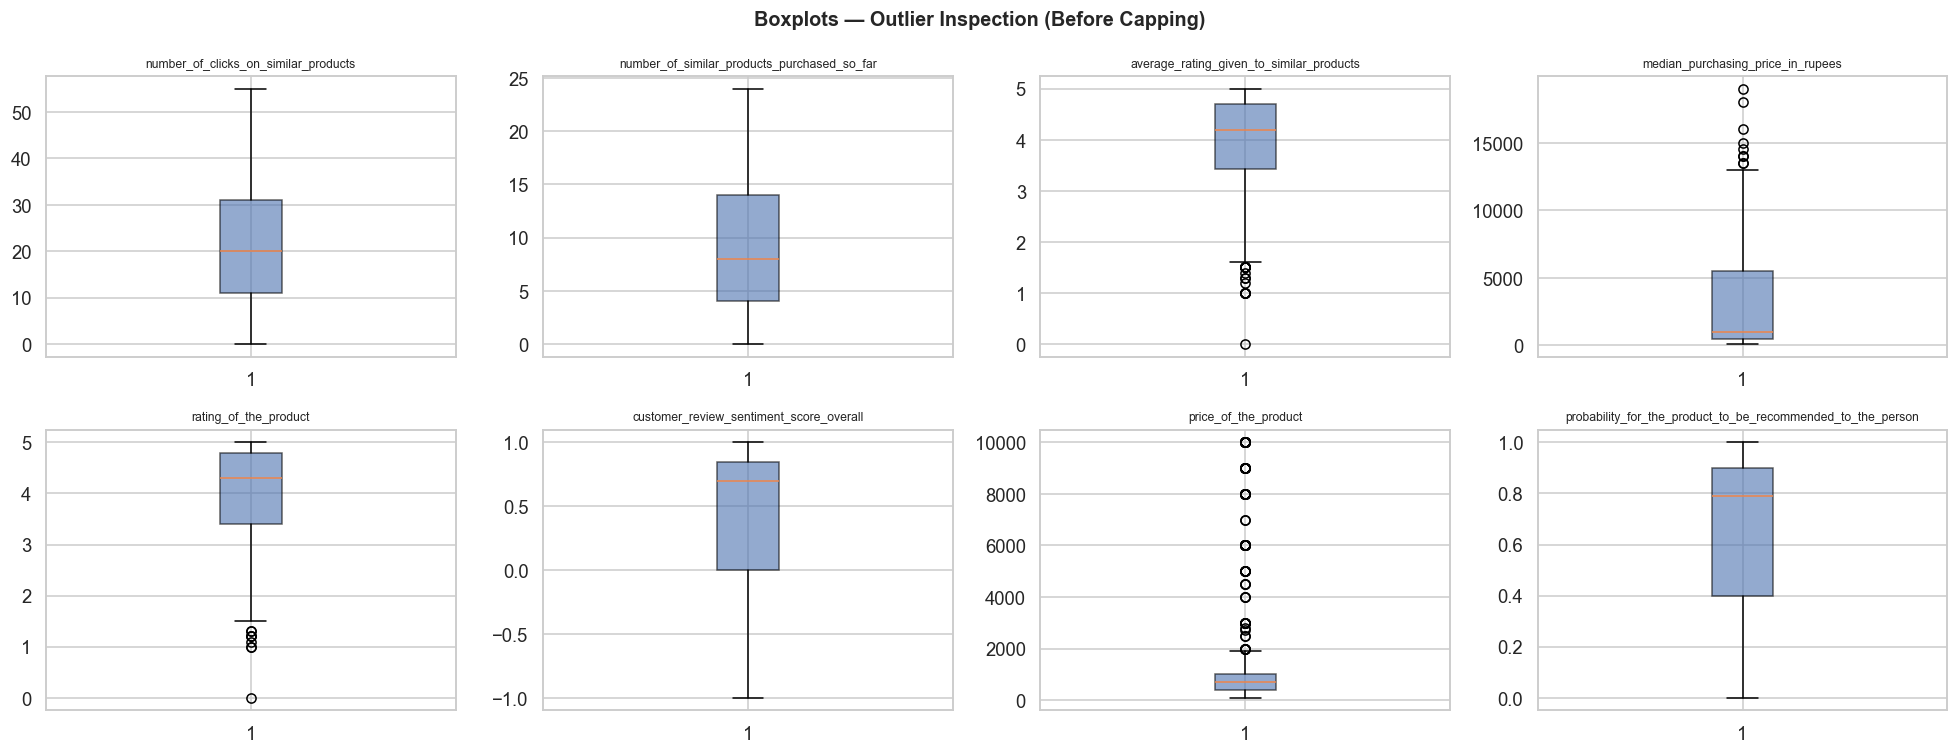

In [15]:
num_cols_clean = df.select_dtypes(include=np.number).columns.tolist()

# ── Boxplots before capping ────────────────────────────────────────────────
ncols = 4
nrows = int(np.ceil(len(num_cols_clean) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols_clean):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6))
    axes[i].set_title(col, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Outlier Inspection (Before Capping)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# ── IQR outlier report ────────────────────────────────────────────────────
outlier_report = []
for col in num_cols_clean:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({'Feature': col, 'Outliers': n_out,
                           'Lower Fence': round(lower, 2), 'Upper Fence': round(upper, 2)})

outlier_df = pd.DataFrame(outlier_report).sort_values('Outliers', ascending=False)
print(outlier_df.to_string(index=False))

                                                    Feature  Outliers  Lower Fence  Upper Fence
                                       price_of_the_product       110    -500.0000    1900.0000
                   average_rating_given_to_similar_products        21       1.5100       6.6100
                          median_purchasing_price_in_rupees         9   -7000.0000   13000.0000
                                      rating_of_the_product         9       1.3000       6.9000
                       number_of_clicks_on_similar_products         0     -19.0000      61.0000
                number_of_similar_products_purchased_so_far         0     -11.0000      29.0000
                    customer_review_sentiment_score_overall         0      -1.2700       2.1200
probability_for_the_product_to_be_recommended_to_the_person         0      -0.3500       1.6500


In [17]:
# ── Winsorise selected columns ────────────────────────────────────────────
# Columns to cap: high-variance behavioural/price features
# Excluded: rating (0–5), probability target (0–1)
cols_to_cap = [
    'number_of_clicks_on_similar_products',
    'number_of_similar_products_purchased_so_far',
    'median_purchasing_price_in_rupees',
    'price_of_the_product'
]

for col in cols_to_cap:
    if col in df.columns:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df[col] = df[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

print(f'✅  Winsorisation applied to {len(cols_to_cap)} columns. Shape: {df.shape}')

✅  Winsorisation applied to 4 columns. Shape: (1018, 13)


---
## 5. 📊 Exploratory Data Analysis (EDA)

### 5.1 Target Distribution

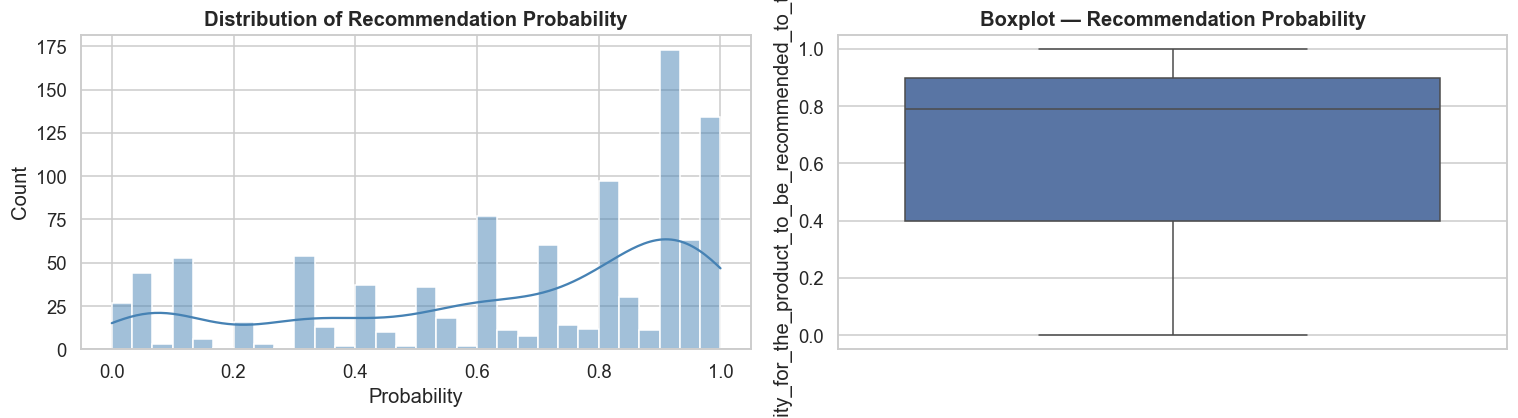

count   1018.0000
mean       0.6561
std        0.3114
min        0.0000
25%        0.4000
50%        0.7900
75%        0.9000
max        1.0000
Name: probability_for_the_product_to_be_recommended_to_the_person, dtype: float64


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram + KDE
sns.histplot(df[TARGET], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Recommendation Probability', fontweight='bold')
axes[0].set_xlabel('Probability')

# Boxplot
sns.boxplot(y=df[TARGET], color='#4C72B0', ax=axes[1])
axes[1].set_title('Boxplot — Recommendation Probability', fontweight='bold')

plt.tight_layout()
plt.show()

print(df[TARGET].describe())

### 5.2 Correlation Heatmap

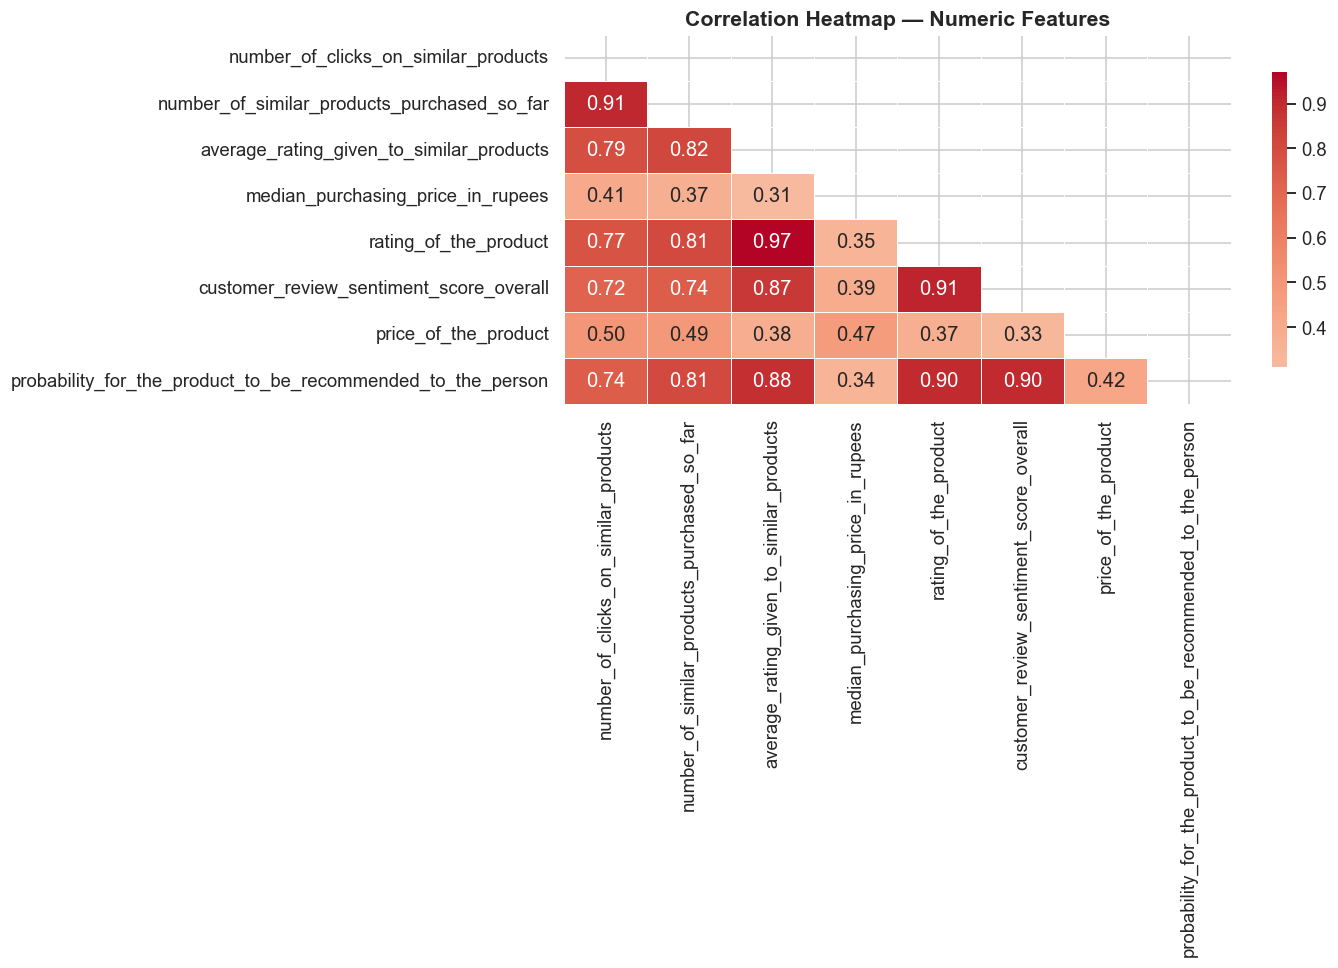


Top correlations with target:
rating_of_the_product                         0.8989
customer_review_sentiment_score_overall       0.8961
average_rating_given_to_similar_products      0.8823
number_of_similar_products_purchased_so_far   0.8091
number_of_clicks_on_similar_products          0.7422
price_of_the_product                          0.4192
median_purchasing_price_in_rupees             0.3432
Name: probability_for_the_product_to_be_recommended_to_the_person, dtype: float64


In [19]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only

plt.figure(figsize=(13, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap=PALETTE, center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
print('\nTop correlations with target:')
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(8))

### 5.3 Numeric Features vs. Target

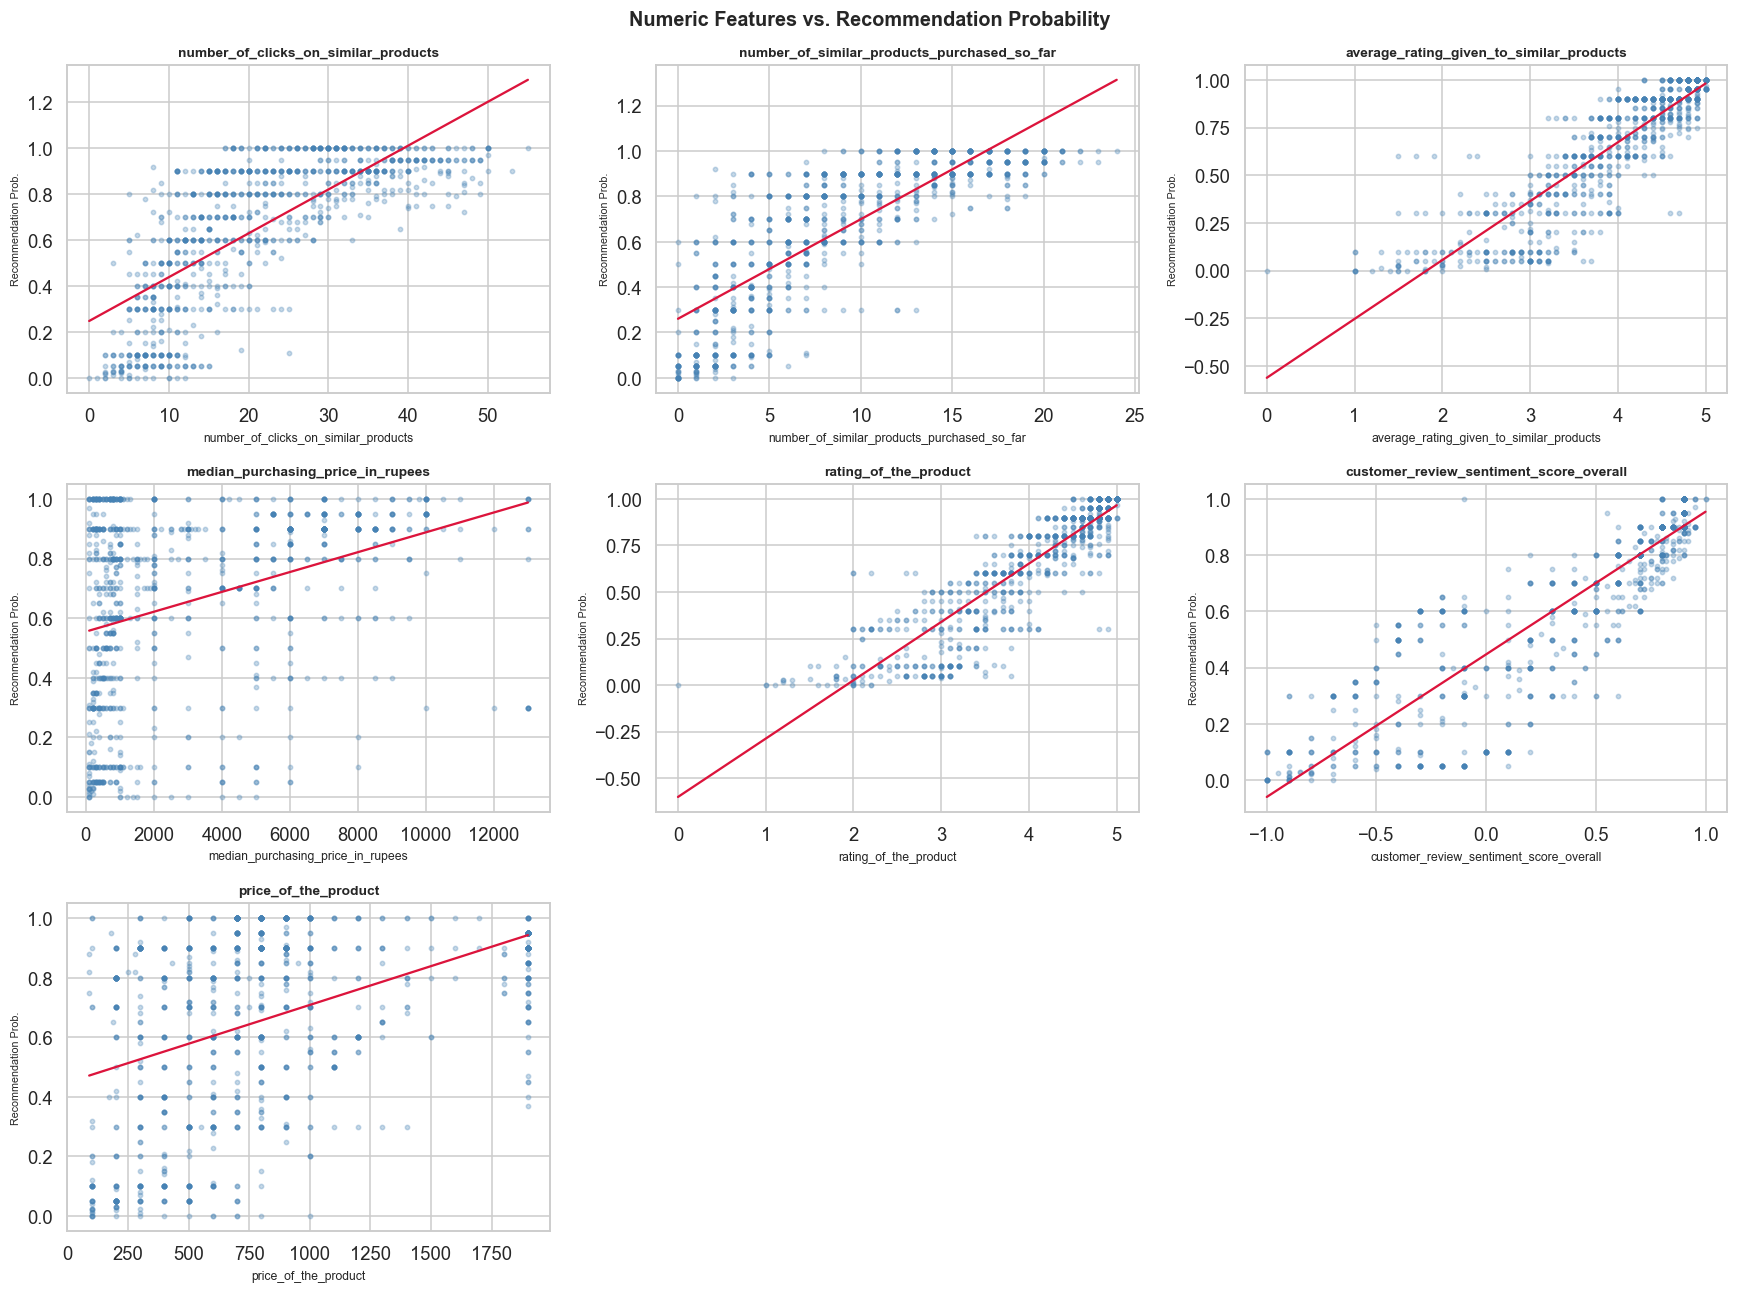

In [20]:
num_features = [c for c in numeric_df.columns if c != TARGET]
ncols = 3
nrows = int(np.ceil(len(num_features) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df[TARGET], alpha=0.3, color='steelblue', s=8)
    # Add a linear trend line
    m, b = np.polyfit(df[col], df[TARGET], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='crimson', lw=1.5, label='trend')
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Recommendation Prob.', fontsize=7)
    axes[i].set_title(col, fontsize=9, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Features vs. Recommendation Probability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Categorical Features vs. Target

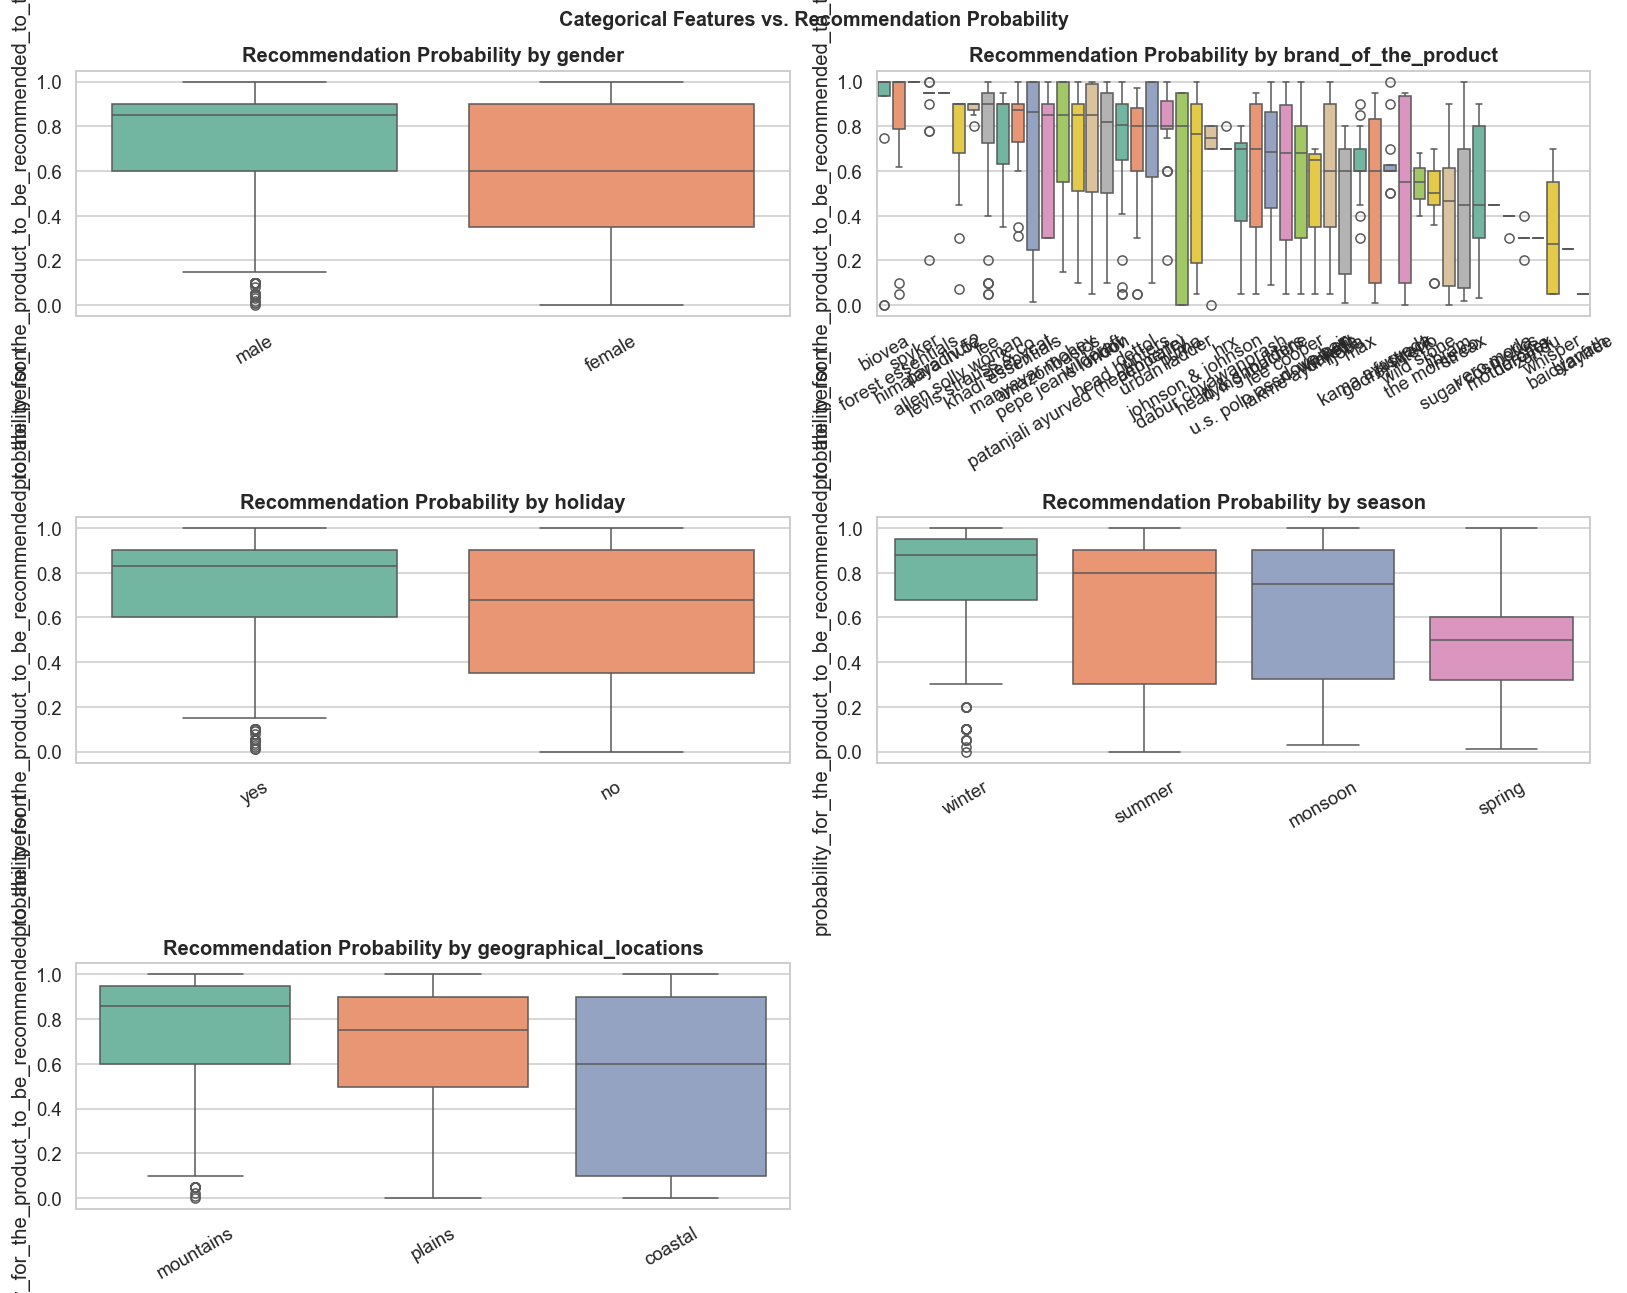

In [21]:
cat_cols_clean = df.select_dtypes(include='object').columns.tolist()

ncols = 2
nrows = int(np.ceil(len(cat_cols_clean) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols_clean):
    order = df.groupby(col)[TARGET].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y=TARGET, order=order,
                palette='Set2', ax=axes[i])
    axes[i].set_title(f'Recommendation Probability by {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs. Recommendation Probability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5 Price vs. Rating — Coloured by Target

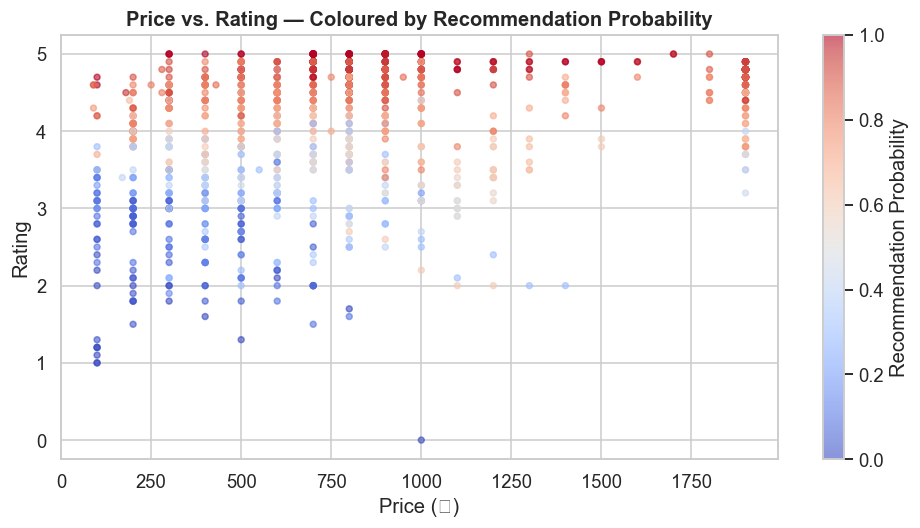

In [22]:
plt.figure(figsize=(9, 5))
sc = plt.scatter(
    df['price_of_the_product'],
    df['rating_of_the_product'],
    c=df[TARGET], cmap=PALETTE, alpha=0.6, s=15
)
plt.colorbar(sc, label='Recommendation Probability')
plt.xlabel('Price (₹)')
plt.ylabel('Rating')
plt.title('Price vs. Rating — Coloured by Recommendation Probability', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. 🔧 Feature Engineering

Creating new features that may capture non-linear relationships better than raw columns.

In [23]:
df_fe = df.copy()

# 1. Engagement Score — total behavioural signal around similar products
df_fe['engagement_score'] = (
    df_fe['number_of_clicks_on_similar_products'] +
    df_fe['number_of_similar_products_purchased_so_far']
)

# 2. Value Ratio — high rating for low price signals a good deal
df_fe['value_ratio'] = df_fe['rating_of_the_product'] / (df_fe['price_of_the_product'] + 1)

# 3. Price Bucket — log-transform smooths heavy right-skew in price
df_fe['log_price'] = np.log1p(df_fe['price_of_the_product'])

# 4. Price vs. Median — how expensive is this product relative to the user's typical spend?
df_fe['price_vs_median'] = df_fe['price_of_the_product'] / (df_fe['median_purchasing_price_in_rupees'] + 1)

new_features = ['engagement_score', 'value_ratio', 'log_price', 'price_vs_median']
print('New features added:')
df_fe[new_features].describe()

New features added:


,engagement_score,value_ratio,log_price,price_vs_median
count,1018.0000,1018.0000,1018.0000,1018.0000
mean,30.4155,0.0076,6.4676,0.8494
std,17.4721,0.0064,0.7066,1.2209
min,0.0000,0.0000,4.5109,0.0143
25%,15.0000,0.0038,5.9940,0.1639
50%,28.0000,0.0059,6.5525,0.4726
75%,44.0000,0.0083,6.9088,0.9975
max,77.0000,0.0505,7.5501,9.9010


In [24]:
# ── Correlation of engineered features with target ─────────────────────────
eng_corr = df_fe[new_features + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print('Correlation of engineered features with target:')
print(eng_corr)

Correlation of engineered features with target:
engagement_score   0.7800
log_price          0.4778
value_ratio        0.1658
price_vs_median    0.0755
Name: probability_for_the_product_to_be_recommended_to_the_person, dtype: float64


---
## 7. 🤖 Modelling

### 7.1 Prepare Features & Target

In [25]:
X = df_fe.drop(TARGET, axis=1)
y = df_fe[TARGET]

# One-hot encode remaining categorical columns
X = pd.get_dummies(X, drop_first=True)

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape        : {y.shape}')
X.head(2)

Feature matrix shape: (1018, 65)
Target shape        : (1018,)


,number_of_clicks_on_similar_products,number_of_similar_products_purchased_so_far,average_rating_given_to_similar_products,median_purchasing_price_in_rupees,rating_of_the_product,customer_review_sentiment_score_overall,price_of_the_product,engagement_score,value_ratio,log_price,price_vs_median,gender_male,brand_of_the_product_amazonbasics,brand_of_the_product_baidyanath,brand_of_the_product_biovea,brand_of_the_product_dabur chyawanprash,brand_of_the_product_dettol,brand_of_the_product_dove hair,brand_of_the_product_duroflex,brand_of_the_product_fastrack,brand_of_the_product_flying machine,brand_of_the_product_forest essentials,brand_of_the_product_godrej interio,brand_of_the_product_head & shoulders,brand_of_the_product_head hunters,brand_of_the_product_himalaya liv.52,brand_of_the_product_hrx,brand_of_the_product_johnson & johnson,brand_of_the_product_kama ayurveda,brand_of_the_product_khadi essentials,brand_of_the_product_lakme ayurveda,brand_of_the_product_lee,brand_of_the_product_lee cooper,brand_of_the_product_levis strauss & co.,brand_of_the_product_libram,brand_of_the_product_lijoba,brand_of_the_product_manyavar mohey,brand_of_the_product_max,brand_of_the_product_moov,brand_of_the_product_mothercare,brand_of_the_product_parachute,brand_of_the_product_patanjali ayurved (health care),brand_of_the_product_pepe jeans london,brand_of_the_product_pepperfry,brand_of_the_product_puma,brand_of_the_product_sleepycat,brand_of_the_product_spyker,brand_of_the_product_stayfree,brand_of_the_product_streax,brand_of_the_product_sugar cosmetics,brand_of_the_product_the moms co.,brand_of_the_product_u.s. polo assn. women,brand_of_the_product_urban ladder,brand_of_the_product_vero moda,brand_of_the_product_wakefit,brand_of_the_product_whisper,brand_of_the_product_wild stone,brand_of_the_product_wildcraft,brand_of_the_product_zandu,holiday_yes,season_spring,season_summer,season_winter,geographical_locations_mountains,geographical_locations_plains
0,12,4,4.2000,500,4.5000,0.8000,200,16,0.0224,5.3033,0.3992,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
1,8,2,3.8000,3000,3.2000,-0.4000,300,10,0.0106,5.7071,0.1000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False


### 7.2 Train / Test Split
> ⚠️ **Split BEFORE scaling** — fitting the scaler on the full dataset leaks test-set statistics into training (data leakage).

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows')

Train: 814 rows  |  Test: 204 rows


### 7.3 Scaling
> Fit the scaler on **train only**, then apply the same transformation to the test set.

In [27]:
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train),  columns=X_train.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),       columns=X_test.columns,  index=X_test.index)

print('Scaling complete ✓')
print(f'X_train_sc mean ≈ {X_train_sc.mean().mean():.4f}  (should be ~0)')
print(f'X_train_sc std  ≈ {X_train_sc.std().mean():.4f}  (should be ~1)')

Scaling complete ✓
X_train_sc mean ≈ -0.0000  (should be ~0)
X_train_sc std  ≈ 0.9852  (should be ~1)


### 7.4 Train & Evaluate All Models

In [28]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model, compute test metrics, and return a results dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # 5-fold cross-validation R² on training set
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')

    return {
        'Model'     : name,
        'R² (test)' : round(r2_score(y_te, y_pred), 4),
        'RMSE'      : round(np.sqrt(mean_squared_error(y_te, y_pred)), 4),
        'MAE'       : round(mean_absolute_error(y_te, y_pred), 4),
        'CV R² (mean)' : round(cv_scores.mean(), 4),
        'CV R² (std)'  : round(cv_scores.std(), 4),
        '_model'    : model,
        '_preds'    : y_pred
    }


models = [
    ('Linear Regression',       LinearRegression(),
     X_train_sc, X_test_sc),
    ('Ridge Regression',        Ridge(alpha=1.0),
     X_train_sc, X_test_sc),
    ('Random Forest',           RandomForestRegressor(n_estimators=200, random_state=42),
     X_train,    X_test),
    ('Gradient Boosting',       GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
     X_train,    X_test),
    ('XGBoost',                 XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbosity=0),
     X_train,    X_test),
]

results = []
for name, model, X_tr, X_te in models:
    print(f'Training {name}...', end=' ')
    res = evaluate_model(name, model, X_tr, y_train, X_te, y_test)
    results.append(res)
    print(f'R²={res["R² (test)"]:.4f}  RMSE={res["RMSE"]:.4f}')

print('\n✅  All models trained.')

Training Linear Regression... R²=0.8800  RMSE=0.1054
Training Ridge Regression... R²=0.8802  RMSE=0.1053
Training Random Forest... R²=0.9417  RMSE=0.0735
Training Gradient Boosting... R²=0.9404  RMSE=0.0742
Training XGBoost... R²=0.9418  RMSE=0.0734

✅  All models trained.


---
## 8. 📈 Model Comparison

In [29]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
results_df = results_df.sort_values('R² (test)', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

            Model  R² (test)   RMSE    MAE  CV R² (mean)  CV R² (std)
          XGBoost     0.9418 0.0734 0.0445        0.9524       0.0111
    Random Forest     0.9417 0.0735 0.0434        0.9532       0.0062
Gradient Boosting     0.9404 0.0742 0.0492        0.9491       0.0079
 Ridge Regression     0.8802 0.1053 0.0777        0.8889       0.0172
Linear Regression     0.8800 0.1054 0.0778        0.8888       0.0174


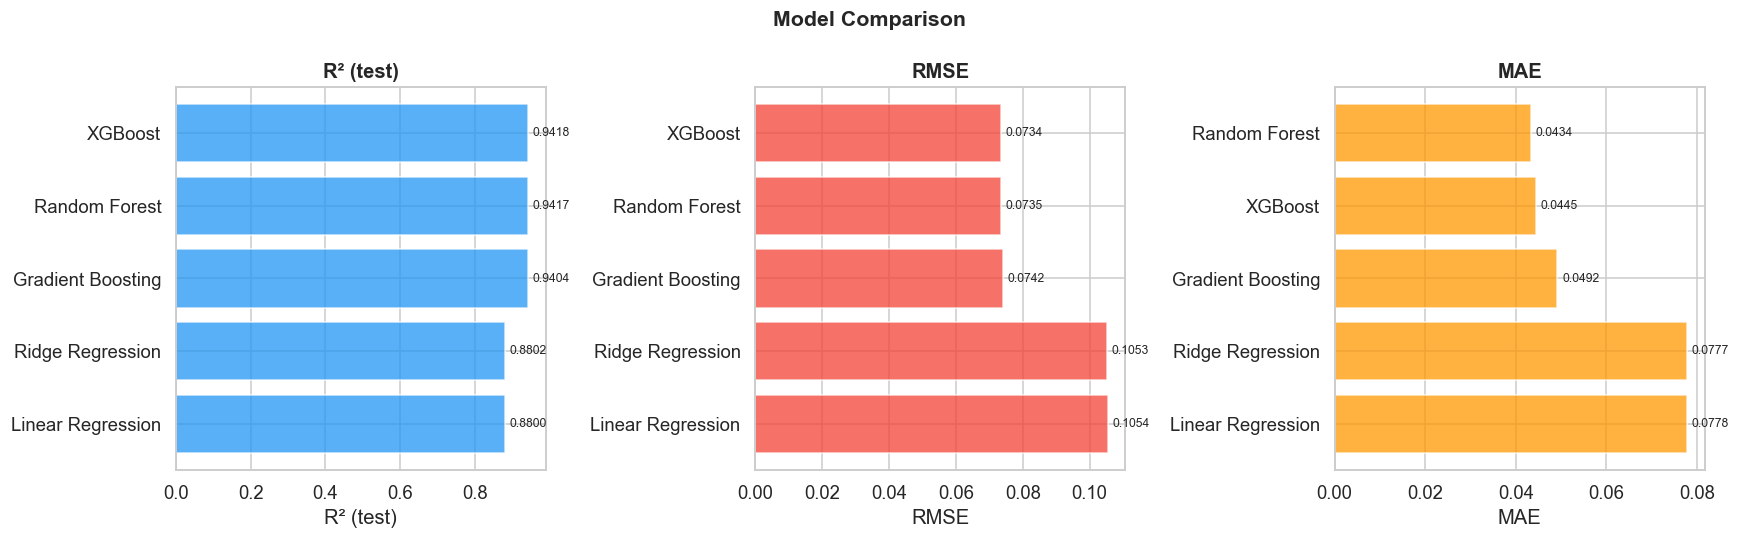

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['R² (test)', 'RMSE', 'MAE']
colors  = ['#2196F3', '#F44336', '#FF9800']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=(metric != 'R² (test)'))
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, alpha=0.75)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    ax.set_xlabel(metric)
    ax.set_title(metric, fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.1 Actual vs. Predicted — Best Model

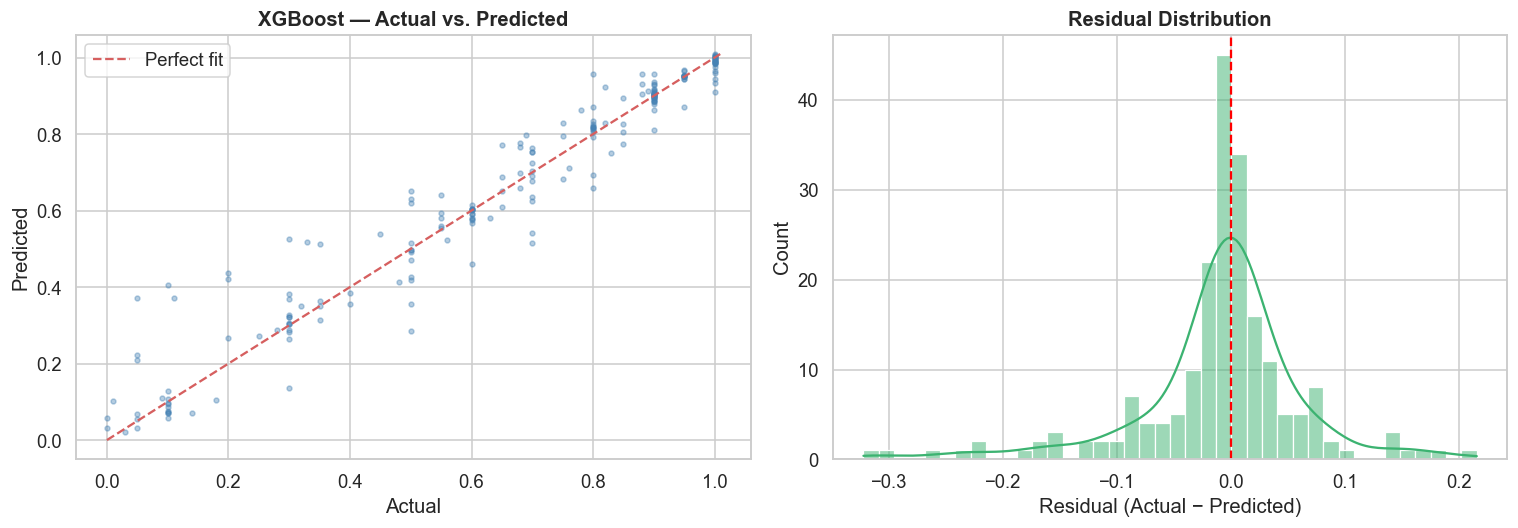

In [31]:
best_name = results_df.iloc[0]['Model']
best_res  = next(r for r in results if r['Model'] == best_name)
y_pred_best = best_res['_preds']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='steelblue', s=10)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_name} — Actual vs. Predicted', fontweight='bold')
axes[0].legend()

# Residuals distribution
residuals = y_test.values - y_pred_best
sns.histplot(residuals, bins=40, kde=True, color='mediumseagreen', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 9. 🌟 Feature Importance — Best Tree Model

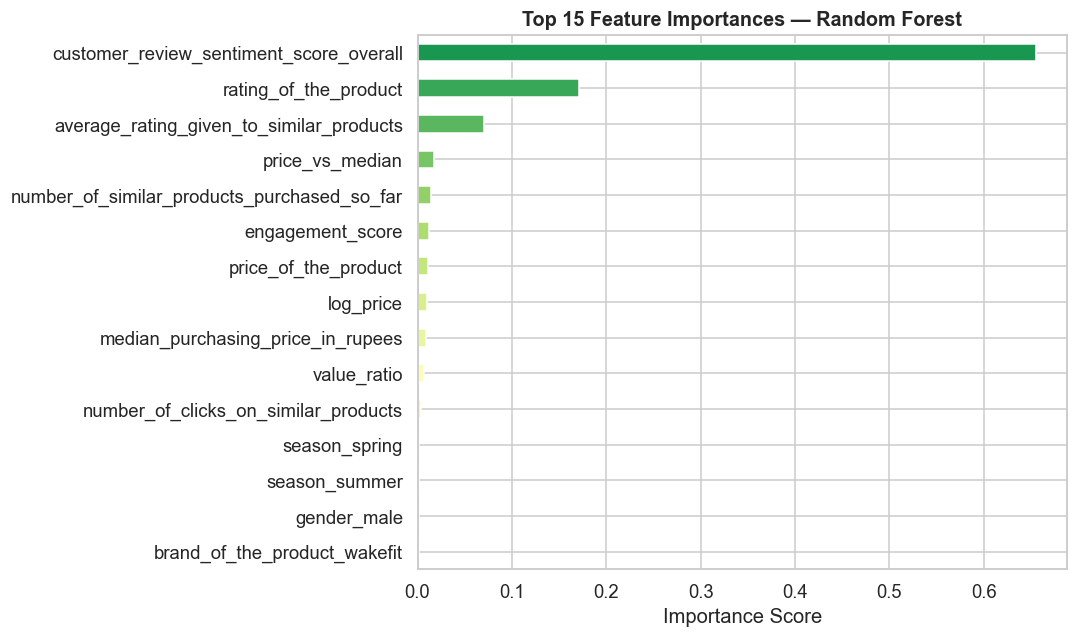

Top 5 most influential features:
customer_review_sentiment_score_overall       0.6557
rating_of_the_product                         0.1707
average_rating_given_to_similar_products      0.0706
price_vs_median                               0.0175
number_of_similar_products_purchased_so_far   0.0139
dtype: float64


In [32]:
# Use the best tree-based model for feature importance
tree_models = ['XGBoost', 'Random Forest', 'Gradient Boosting']
best_tree   = next((r for r in results if r['Model'] in tree_models), None)

if best_tree:
    importances = pd.Series(
        best_tree['_model'].feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=True)

    top_n = 15
    plt.figure(figsize=(10, 6))
    importances.tail(top_n).plot(
        kind='barh',
        color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))
    )
    plt.title(f'Top {top_n} Feature Importances — {best_tree["Model"]}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print('Top 5 most influential features:')
    print(importances.tail(5).iloc[::-1])

---
## 10. ✅ Final Summary

### Cleaning & Pipeline Recap
| Step | Action |
|------|--------|
| Missing values | Median / mode imputation (no leakage) |
| Duplicates | Removed and index reset |
| Categorical standardisation | Stripped whitespace, lowercased |
| Column naming | Renamed to consistent snake_case |
| Outliers | Winsorised with IQR on selected columns |
| Feature engineering | engagement_score, value_ratio, log_price, price_vs_median |
| Encoding | One-hot with `drop_first=True` |
| Scaling | `StandardScaler` fit on train only |
| Train / Test split | 80 / 20, random_state=42 |

### Model Results

In [33]:
print('='*65)
print('             FINAL MODEL COMPARISON SUMMARY')
print('='*65)
print(results_df[['Model','R² (test)','RMSE','MAE','CV R² (mean)','CV R² (std)']].to_string(index=False))
print('='*65)
print(f'\n🏆  Best model : {results_df.iloc[0]["Model"]}')
print(f'   Test R²    : {results_df.iloc[0]["R² (test)"]}')
print(f'   RMSE       : {results_df.iloc[0]["RMSE"]}')

             FINAL MODEL COMPARISON SUMMARY
            Model  R² (test)   RMSE    MAE  CV R² (mean)  CV R² (std)
          XGBoost     0.9418 0.0734 0.0445        0.9524       0.0111
    Random Forest     0.9417 0.0735 0.0434        0.9532       0.0062
Gradient Boosting     0.9404 0.0742 0.0492        0.9491       0.0079
 Ridge Regression     0.8802 0.1053 0.0777        0.8889       0.0172
Linear Regression     0.8800 0.1054 0.0778        0.8888       0.0174

🏆  Best model : XGBoost
   Test R²    : 0.9418
   RMSE       : 0.0734


---
## 11. 💡 Key Takeaways & Next Steps

**What we learned:**
- *[Fill in after running — e.g. "Rating and engagement_score were the strongest predictors."]*
- Tree-based ensemble models outperformed linear baselines, suggesting non-linear patterns in the data.
- The engineered `value_ratio` feature added meaningful signal beyond raw price and rating.

**Potential improvements:**
1. **Hyperparameter tuning** — Use `GridSearchCV` or `Optuna` to optimise the best model.
2. **SHAP explanations** — Add `shap.TreeExplainer` for interpretable, per-prediction explanations.
3. **Larger dataset** — More user/product interaction history would likely improve generalisation.
4. **Collaborative filtering** — Combine this content-based approach with user-user or item-item similarity.
5. **Deployment** — Wrap the model pipeline in a `sklearn.pipeline.Pipeline` and serialise with `joblib` for production use.